In [1]:
# Step 1: Import Necessary Libraries
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import image, plotting, masking, datasets
from nilearn.input_data import NiftiMasker
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score 
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [2]:
import os

def get_bold_file_paths(base_dir):
    control_subjects = []
    non_dyslexic_subjects = []
    control_ids = {11, 12, 13, 18, 19, 23, 24, 25, 26, 29, 30, 31, 32, 33, 34, 35, 36, 37, 40, 41}
    
    for sub_num in range(1, 43):  # Looping from sub-01 to sub-42
        sub_folder = f"sub-{sub_num:02d}"  # Format to ensure two-digit numbering
        #func_path = os.path.join(base_dir, sub_folder, "func")
        func_path = os.path.join(base_dir, sub_folder)
        
        if os.path.exists(func_path):
            for file in os.listdir(func_path):
                if file.endswith(("task-morphosem_run-01_bold.nii.gz","task-morphosem_run-02_bold.nii.gz","task-morphosem_run-03_bold.nii.gz","task-morphosem_run-04_bold.nii.gz")):
                    file_path = os.path.join(func_path, file)
                    if sub_num in control_ids:
                        control_subjects.append(file_path)
                    else:
                        non_dyslexic_subjects.append(file_path)
    
    return control_subjects, non_dyslexic_subjects

# Set the base directory
#base_directory = r"D:\project_7th_sem\ds004786-download"
base_directory = r"D:\myResearch\Dataset01_MorphoSem"

# Get the list of file paths
control_subjects, non_dyslexic_subjects = get_bold_file_paths(base_directory)

# Print the lists
print("Control Subjects:")
for i,path in enumerate(control_subjects):
    print(path)

print("\nNon-Dyslexic Subjects:")
for j,path in enumerate(non_dyslexic_subjects):
    print(path)

print (i)
print (j)

print(len(control_subjects),len(non_dyslexic_subjects))

Control Subjects:
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-04_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-04_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-04_bold.nii.g

[get_dataset_dir] Dataset found in C:\Users\utpal\nilearn_data\fsl

0: Background
1: Frontal Pole
2: Insular Cortex
3: Superior Frontal Gyrus
4: Middle Frontal Gyrus
5: Inferior Frontal Gyrus, pars triangularis
6: Inferior Frontal Gyrus, pars opercularis
7: Precentral Gyrus
8: Temporal Pole
9: Superior Temporal Gyrus, anterior division
10: Superior Temporal Gyrus, posterior division
11: Middle Temporal Gyrus, anterior division
12: Middle Temporal Gyrus, posterior division
13: Middle Temporal Gyrus, temporooccipital part
14: Inferior Temporal Gyrus, anterior division
15: Inferior Temporal Gyrus, posterior division
16: Inferior Temporal Gyrus, temporooccipital part
17: Postcentral Gyrus
18: Superior Parietal Lobule
19: Supramarginal Gyrus, anterior division
20: Supramarginal Gyrus, posterior division
21: Angular Gyrus
22: Lateral Occipital Cortex, superior division
23: Lateral Occipital Cortex, inferior division
24: Intracalcarine Cortex
25: Frontal Medial Cortex
26: Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)
27: Subcallosal Cort

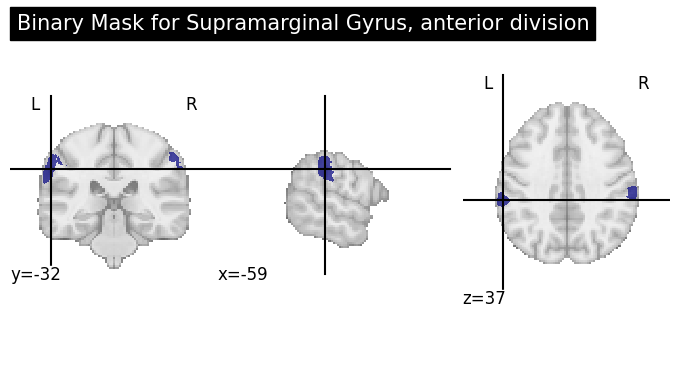

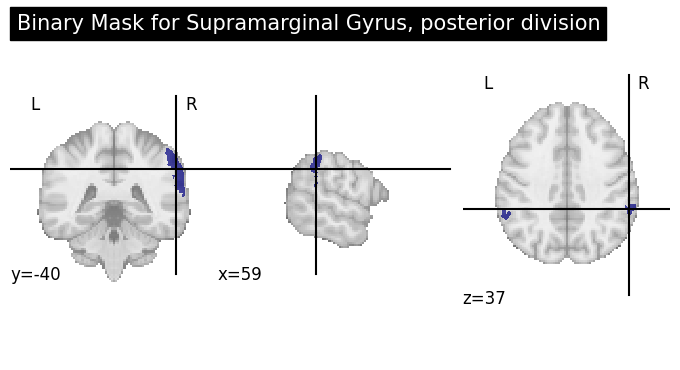

In [3]:
# Step 2: Load the Harvard-Oxford atlas and select a specific region
from nilearn.image import math_img

# Load the Harvard-Oxford cortical atlas (probabilistic map)
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr50-1mm')
atlas_img = atlas['maps']
atlas_labels = atlas['labels']

# Print available region labels to confirm the correct region index
for idx, label in enumerate(atlas_labels):
    print(f"{idx}: {label}")

# Select the index for the desired region (e.g., Inferior Frontal Gyrus, pars triangularis)
region_name1 = "Supramarginal Gyrus, anterior division"  # Region of Interest
region_idx1 = atlas_labels.index(region_name1)  # Find index for Inferior Frontal Gyrus, pars triangularis
# Create a binary mask for the selected region
binary_mask1 = math_img(f"img == {region_idx1}", img=atlas_img)
# Visualize the binary mask to ensure it's correctly created
plotting.plot_roi(binary_mask1, title=f"Binary Mask for {region_name1}", display_mode='ortho')
plotting.show()

# Select the index for the desired region (e.g., Inferior Frontal Gyrus, pars opercularis)
region_name2 = "Supramarginal Gyrus, posterior division"  # Region of Interest
region_idx2 = atlas_labels.index(region_name2)  # Find index for Inferior Frontal Gyrus, pars opercularis 
# Create a binary mask for the selected region
binary_mask2 = math_img(f"img == {region_idx2}", img=atlas_img)
# Visualize the binary mask to ensure it's correctly created
plotting.plot_roi(binary_mask2, title=f"Binary Mask for {region_name2}", display_mode='ortho')
plotting.show()


## Loading a single ROI **(MEAN)**:- 1) Supramarginal Gyrus-Anterior Division
#### Then performing the experiments.

In [4]:
####Loading the saved dataset in np format.
cmd1 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/control_mean_anterior_division.npz")
ndmd1 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/non_dyslexic_mean_anterior_division.npz")
control_mean_data1 = cmd1["control_mean_data1"]
non_dyslexic_mean_data1=ndmd1["non_dyslexic_mean_data1"]
####
print(len(control_mean_data1))
print(len(non_dyslexic_mean_data1))
print(control_mean_data1[0].shape)
print(non_dyslexic_mean_data1[0].shape)
#print(control_mean_data1[79][2376])

# Combine the aggregated data from both groups
X = np.vstack([control_mean_data1, non_dyslexic_mean_data1])  # Shape: (n_samples, n_voxels)
y = np.array([1] * len(control_mean_data1) + [0] * len(non_dyslexic_mean_data1))  # Binary labels

print(X.shape)
print(y.shape)

80
80
(5153,)
(5153,)
(160, 5153)
(160,)


Training Accuracy on Supramarginal Gyrus- anterior division (Logistic Regression): 100.00%
Testing Accuracy on Supramarginal Gyrus- anterior division (Logistic Regression): 53.12%

Classification Report for Testing Data on Supramarginal Gyrus- anterior division (Logistic Regression):
              precision    recall  f1-score   support

           0       0.52      0.69      0.59        16
           1       0.55      0.38      0.44        16

    accuracy                           0.53        32
   macro avg       0.53      0.53      0.52        32
weighted avg       0.53      0.53      0.52        32


ROC-AUC score for Testing Data on Supramarginal Gyrus- anterior division (Logistic Regression): 0.53


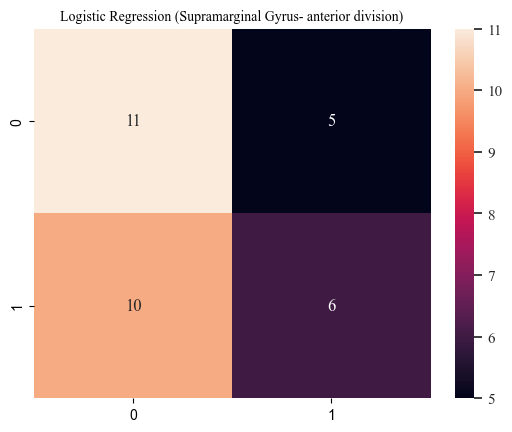

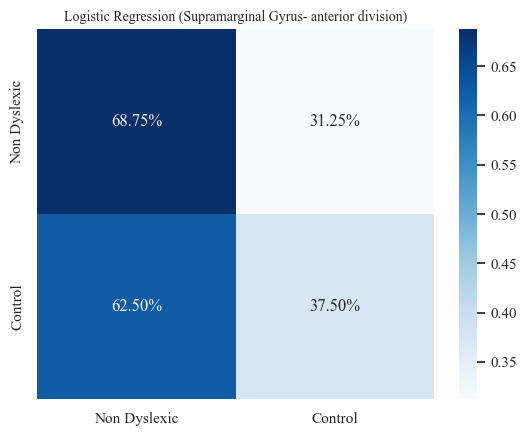

In [5]:
##### Logistic regression model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print both accuracies
print(f"Training Accuracy on Supramarginal Gyrus- anterior division (Logistic Regression): {log_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus- anterior division (Logistic Regression): {log_mean_test_accuracy_ROI1 * 100:.2f}%")

# Optionally, print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus- anterior division (Logistic Regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus- anterior division (Logistic Regression): {log_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
#print(cm)
plt.title('Logistic Regression (Supramarginal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_1(Log_Reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic Regression (Supramarginal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Temporal_Gyrus_ROI_1(Log_Reg)_percent.png", dpi=600)
plt.show()

Training Accuracy on Supramarginal Gyrus- anterior division (Support Vector Machine): 70.31%
Testing Accuracy on Supramarginal Gyrus- anterior division (Support Vector Machine): 46.88%

Classification Report for Testing Data on Supramarginal Gyrus- anterior division (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.44      0.25      0.32        16
           1       0.48      0.69      0.56        16

    accuracy                           0.47        32
   macro avg       0.46      0.47      0.44        32
weighted avg       0.46      0.47      0.44        32


ROC-AUC score for Testing Data on Supramarginal Gyrus- anterior division (Support Vector Machine): 0.47


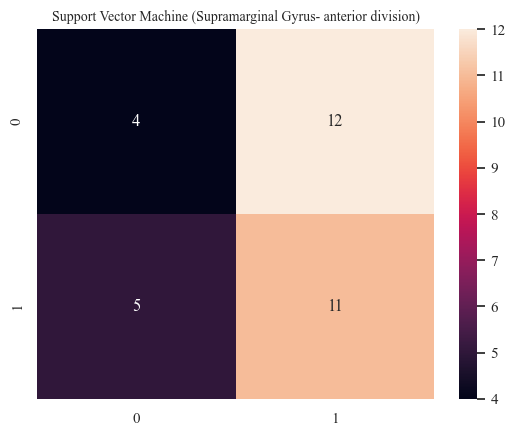

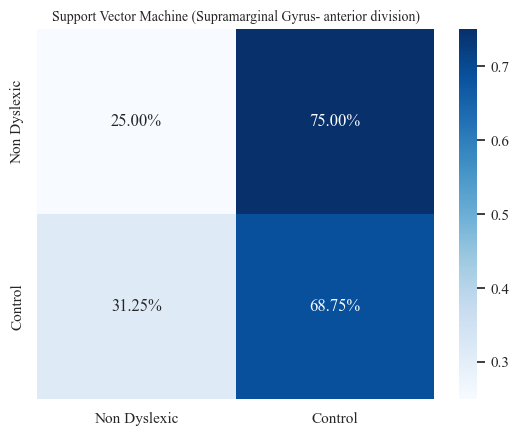

In [6]:
###### SVM model

# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Calculate training and testing accuracy
svm_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Supramarginal Gyrus- anterior division (Support Vector Machine): {svm_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus- anterior division (Support Vector Machine): {svm_mean_test_accuracy_ROI1 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus- anterior division (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus- anterior division (Support Vector Machine): {svm_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine (Supramarginal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_1(SVM)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Supramarginal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_1(SVM)_percent.png", dpi=600)
plt.show()

Training Accuracy on Supramarginal Gyrus- anterior division (k-nearest neighbors): 53.12%
Testing Accuracy on Supramarginal Gyrus- anterior division (k-nearest neighbors): 46.88%

Classification Report for Testing Data on Supramarginal Gyrus- anterior division (k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.48      0.94      0.64        16
           1       0.00      0.00      0.00        16

    accuracy                           0.47        32
   macro avg       0.24      0.47      0.32        32
weighted avg       0.24      0.47      0.32        32


ROC-AUC score for Testing Data on Supramarginal Gyrus- anterior division (k-nearest neighbors): 0.47


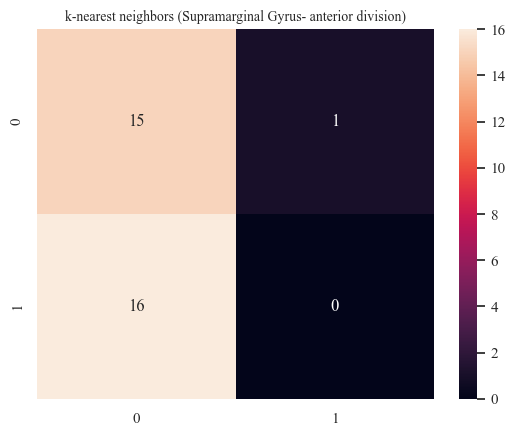

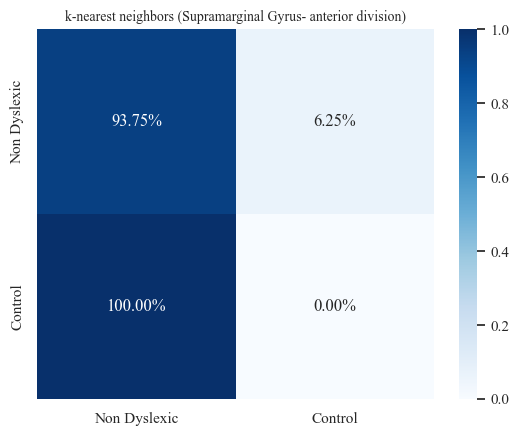

In [7]:
##### KNN model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Supramarginal Gyrus- anterior division (k-nearest neighbors): {knn_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus- anterior division (k-nearest neighbors): {knn_mean_test_accuracy_ROI1 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus- anterior division (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus- anterior division (k-nearest neighbors): {knn_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors (Supramarginal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_1(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Supramarginal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_1(KNN)_percent.png", dpi=600)
plt.show()

Total Training set:-  Dataset:- (128, 5153) Label:- (128,)
Total Testing set:-  Dataset:- (32, 5153) Label:- (32,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │       2,638,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,712,833 (10.35 MB)

 Trainable params: 2,712,833 (10.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.5260 - loss: 0.7303
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9479 - loss: 0.3233
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9792 - loss: 0.2496
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9948 - loss: 0.1680
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.1106
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9948 - loss: 0.0605
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9948 - loss: 0.0313
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9896 - loss: 0.0234
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.0173
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9948 - loss: 0.0063
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.0040    
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.00

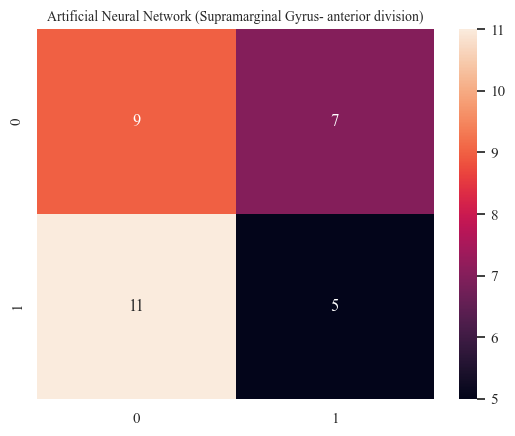

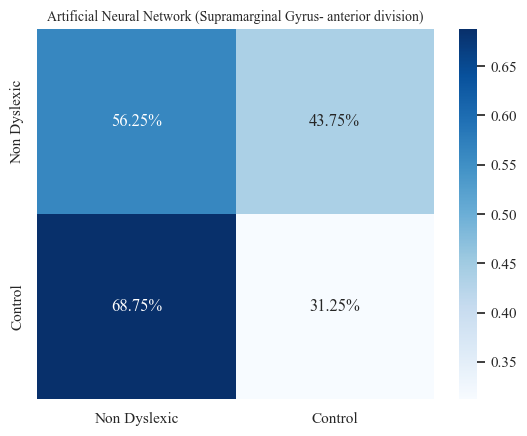

In [8]:
###### ANN Model

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])
# define the input shape
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=input_shape))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
ann_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Supramarginal Gyrus- anterior division (Artificial Neural Network): {ann_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus- anterior division (Artificial Neural Network): {ann_mean_test_accuracy_ROI1 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus- anterior division (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))

ann_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus- anterior division (Artificial Neural Network): {ann_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network (Supramarginal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_1(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Supramarginal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_1(ANN)_percent.png", dpi=600)
plt.show()

Training Accuracy on Supramarginal Gyrus- anterior division (Random Forest): 100.00%
Testing Accuracy on Supramarginal Gyrus- anterior division (Random Forest): 59.38%

Classification Report for Testing Data on Supramarginal Gyrus- anterior division (Random Forest):
              precision    recall  f1-score   support

           0       0.59      0.62      0.61        16
           1       0.60      0.56      0.58        16

    accuracy                           0.59        32
   macro avg       0.59      0.59      0.59        32
weighted avg       0.59      0.59      0.59        32


ROC-AUC score for Testing Data on Supramarginal Gyrus- anterior division (Random Forest): 0.59


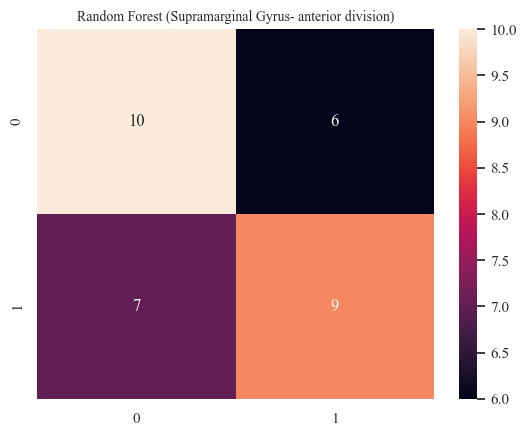

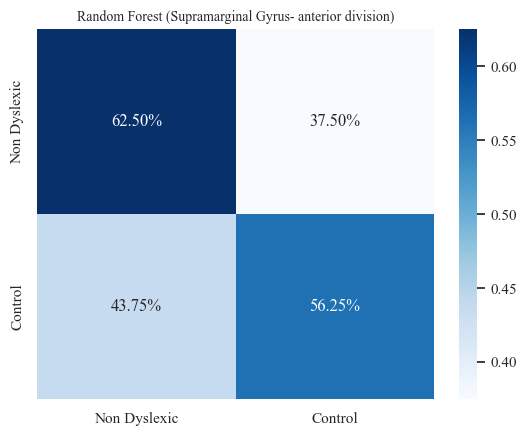

In [9]:
##### Random Forest model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print both accuracies
print(f"Training Accuracy on Supramarginal Gyrus- anterior division (Random Forest): {rf_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus- anterior division (Random Forest): {rf_mean_test_accuracy_ROI1 * 100:.2f}%")

# Optionally, print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus- anterior division (Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus- anterior division (Random Forest): {rf_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
#print(cm)
plt.title('Random Forest (Supramarginal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_1(Rand_Forst)_simple.png", dpi=600)
plt.show() 
plt.title('Random Forest (Supramarginal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Temporal_Gyrus_ROI_1(Rand_Forst)_percent.png", dpi=600)
plt.show()

Training Accuracy on Supramarginal Gyrus- anterior division (XGBoost): 100.00%
Testing Accuracy on Supramarginal Gyrus- anterior division (XGBoost: 62.50%

Classification Report for Testing Data on Supramarginal Gyrus- anterior division (XGBoost):
              precision    recall  f1-score   support

           0       0.64      0.56      0.60        16
           1       0.61      0.69      0.65        16

    accuracy                           0.62        32
   macro avg       0.63      0.62      0.62        32
weighted avg       0.63      0.62      0.62        32


ROC-AUC score for Testing Data on Supramarginal Gyrus- anterior division (XGBoost): 0.62


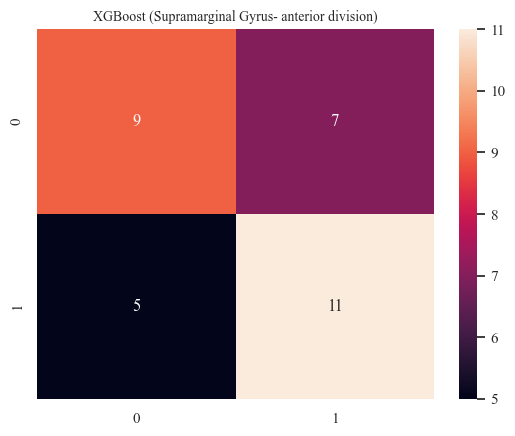

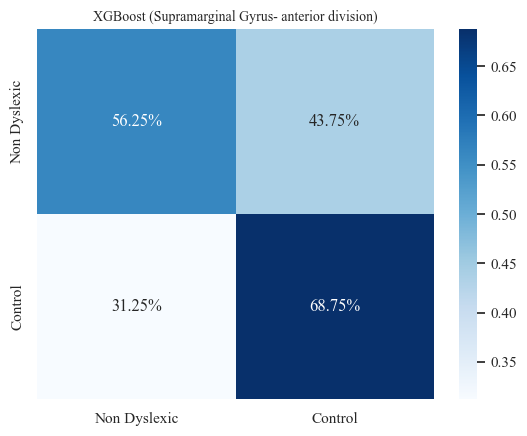

In [10]:
##### XGBoost (eXtreme Gradient Boosting) model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print both accuracies
print(f"Training Accuracy on Supramarginal Gyrus- anterior division (XGBoost): {xgb_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus- anterior division (XGBoost: {xgb_mean_test_accuracy_ROI1 * 100:.2f}%")

# Optionally, print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus- anterior division (XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus- anterior division (XGBoost): {xgb_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
#print(cm)
plt.title('XGBoost (Supramarginal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_1(XGBst)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Supramarginal Gyrus- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Temporal_Gyrus_ROI_1(XGBst)_percent.png", dpi=600)
plt.show()

In [11]:
mean1=[]
mean1.append([round(log_mean_prf_ROI1[0][0],2),round(log_mean_prf_ROI1[1][0],2),round(log_mean_prf_ROI1[2][0],2),round(log_mean_test_accuracy_ROI1,2),round(log_mean_roc_ROI1,2)])
mean1.append([round(log_mean_prf_ROI1[0][1],2),round(log_mean_prf_ROI1[1][1],2),round(log_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(svm_mean_prf_ROI1[0][0],2),round(svm_mean_prf_ROI1[1][0],2),round(svm_mean_prf_ROI1[2][0],2),round(svm_mean_test_accuracy_ROI1,2),round(svm_mean_roc_ROI1,2)])
mean1.append([round(svm_mean_prf_ROI1[0][1],2),round(svm_mean_prf_ROI1[1][1],2),round(svm_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(knn_mean_prf_ROI1[0][0],2),round(knn_mean_prf_ROI1[1][0],2),round(knn_mean_prf_ROI1[2][0],2),round(knn_mean_test_accuracy_ROI1,2),round(knn_mean_roc_ROI1,2)])
mean1.append([round(knn_mean_prf_ROI1[0][1],2),round(knn_mean_prf_ROI1[1][1],2),round(knn_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(ann_mean_prf_ROI1[0][0],2),round(ann_mean_prf_ROI1[1][0],2),round(ann_mean_prf_ROI1[2][0],2),round(ann_mean_test_accuracy_ROI1,2),round(ann_mean_roc_ROI1,2)])
mean1.append([round(ann_mean_prf_ROI1[0][1],2),round(ann_mean_prf_ROI1[1][1],2),round(ann_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(rf_mean_prf_ROI1[0][0],2),round(rf_mean_prf_ROI1[1][0],2),round(rf_mean_prf_ROI1[2][0],2),round(rf_mean_test_accuracy_ROI1,2),round(rf_mean_roc_ROI1,2)])
mean1.append([round(rf_mean_prf_ROI1[0][1],2),round(rf_mean_prf_ROI1[1][1],2),round(rf_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(xgb_mean_prf_ROI1[0][0],2),round(xgb_mean_prf_ROI1[1][0],2),round(xgb_mean_prf_ROI1[2][0],2),round(xgb_mean_test_accuracy_ROI1,2),round(xgb_mean_roc_ROI1,2)])
mean1.append([round(xgb_mean_prf_ROI1[0][1],2),round(xgb_mean_prf_ROI1[1][1],2),round(xgb_mean_prf_ROI1[2][1],2),'',''])

df1 = pd.DataFrame(mean1,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Control']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
#df=df.style.set_sticky(axis="index")
df1=df1.style.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}])
display(df1)
df1.to_excel('../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Table_Mean_ROI_1_Supramarginal_Gyrus.xlsx', engine='openpyxl')


## Loading a single ROI **(MEAN)**:- 2. Supramarginal Gyrus-Posterior Division
#### Then performing the experiments.

In [12]:
####Loading the saved dataset in np format.
cmd2 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/control_mean_posterior_division.npz")
ndmd2 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/non_dyslexic_mean_posterior_division.npz")
control_mean_data2 = cmd2["control_mean_data2"]
non_dyslexic_mean_data2=ndmd2["non_dyslexic_mean_data2"]
####
print(len(control_mean_data2))
print(len(non_dyslexic_mean_data2))
print(control_mean_data2[0].shape)
print(non_dyslexic_mean_data2[0].shape)

# Combine the aggregated data from both groups
X = np.vstack([control_mean_data2, non_dyslexic_mean_data2])  # Shape: (n_samples, n_voxels)
y = np.array([1] * len(control_mean_data2) + [0] * len(non_dyslexic_mean_data2))  # Binary labels

print(X.shape)
print(y.shape)

80
80
(4273,)
(4273,)
(160, 4273)
(160,)


Training Accuracy on Supramarginal Gyrus- posterior division (Logistic regression): 100.00%
Testing Accuracy on Supramarginal Gyrus- posterior division (Logistic regression): 56.25%

Classification Report for Testing Data on Supramarginal Gyrus- posterior division (Logistic regression):
              precision    recall  f1-score   support

           0       0.55      0.69      0.61        16
           1       0.58      0.44      0.50        16

    accuracy                           0.56        32
   macro avg       0.57      0.56      0.56        32
weighted avg       0.57      0.56      0.56        32


ROC-AUC score for Testing Data on Supramarginal Gyrus- posterior division (Logistic Regression): 0.56


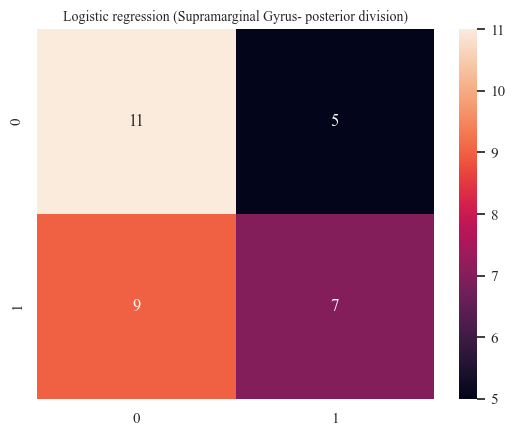

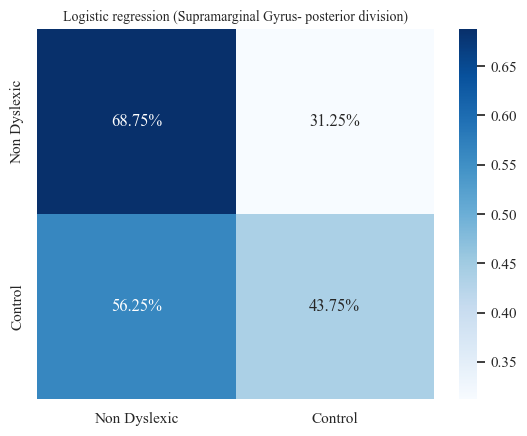

In [13]:
##### Logistic regression model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Supramarginal Gyrus- posterior division (Logistic regression): {log_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus- posterior division (Logistic regression): {log_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus- posterior division (Logistic regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus- posterior division (Logistic Regression): {log_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Logistic regression (Supramarginal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_2(log_reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic regression (Supramarginal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_2(log_reg)_percent.png", dpi=600)
plt.show()

Training Accuracy on Supramarginal Gyrus- posterior division (Support Vector Machine): 70.31%
Testing Accuracy on Supramarginal Gyrus- posterior division (Support Vector Machine): 43.75%

Classification Report for Testing Data on Supramarginal Gyrus- posterior division (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.43      0.38      0.40        16
           1       0.44      0.50      0.47        16

    accuracy                           0.44        32
   macro avg       0.44      0.44      0.44        32
weighted avg       0.44      0.44      0.44        32


ROC-AUC score for Testing Data on Supramarginal Gyrus- posterior division (Support Vector Machine): 0.44


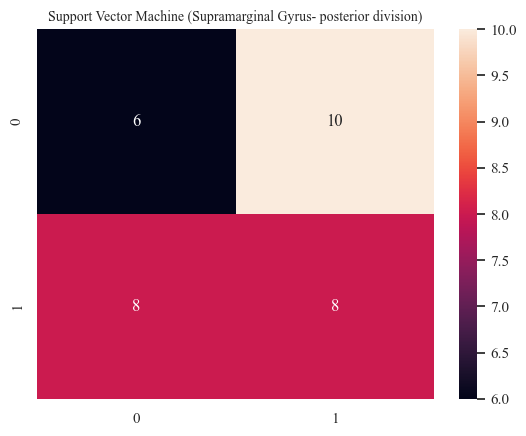

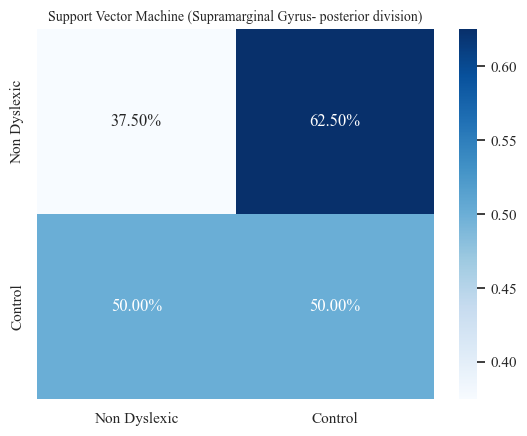

In [14]:
##### SVM model

# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Evaluate the model
svm_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Supramarginal Gyrus- posterior division (Support Vector Machine): {svm_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus- posterior division (Support Vector Machine): {svm_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus- posterior division (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus- posterior division (Support Vector Machine): {svm_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine (Supramarginal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_2(SVM)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Supramarginal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_2(SVM)_percent.png", dpi=600)
plt.show()

Training Accuracy on Supramarginal Gyrus- posterior division (k-nearest neighbors): 51.56%
Testing Accuracy on Supramarginal Gyrus- posterior division (k-nearest neighbors): 50.00%

Classification Report for Testing Data on Supramarginal Gyrus- posterior division (k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.50      1.00      0.67        16
           1       0.00      0.00      0.00        16

    accuracy                           0.50        32
   macro avg       0.25      0.50      0.33        32
weighted avg       0.25      0.50      0.33        32


ROC-AUC score for Testing Data on Supramarginal Gyrus- posterior division (k-nearest neighbors): 0.50


D:\Aanaconda3\envs\env_sih\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Aanaconda3\envs\env_sih\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Aanaconda3\envs\env_sih\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Aanaconda3\envs\env_sih\lib\sit

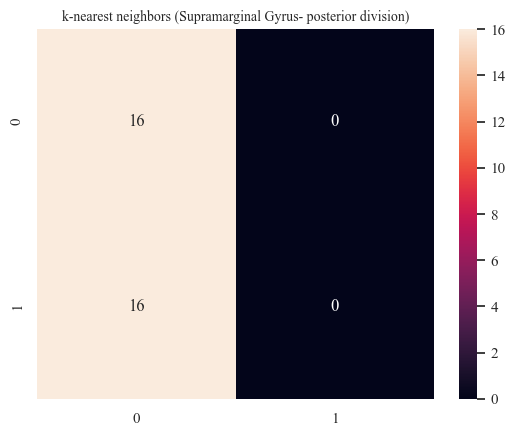

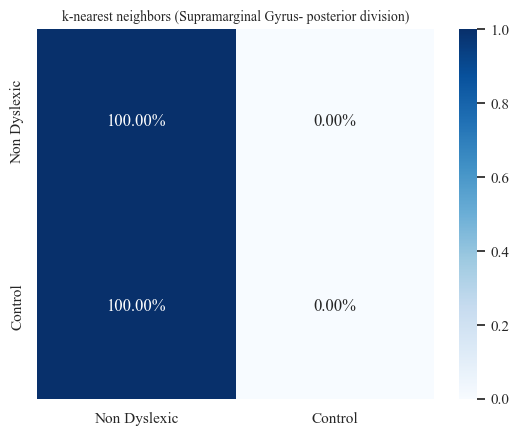

In [15]:
##### KNN model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Supramarginal Gyrus- posterior division (k-nearest neighbors): {knn_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus- posterior division (k-nearest neighbors): {knn_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus- posterior division (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus- posterior division (k-nearest neighbors): {knn_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors (Supramarginal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_2(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Supramarginal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_2(KNN)_percent.png", dpi=600)
plt.show()

Total Training set:-  Dataset:- (128, 4273) Label:- (128,)
Total Testing set:-  Dataset:- (32, 4273) Label:- (32,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 512)                 │       2,188,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,262,273 (8.63 MB)

 Trainable params: 2,262,273 (8.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.4583 - loss: 0.7969 
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8490 - loss: 0.3674
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8854 - loss: 0.3138
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9375 - loss: 0.2350
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.1733
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.1127
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0793
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9948 - loss: 0.0501
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.0258
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0214
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9948 - loss: 0.0129
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9896 - loss: 0.0123


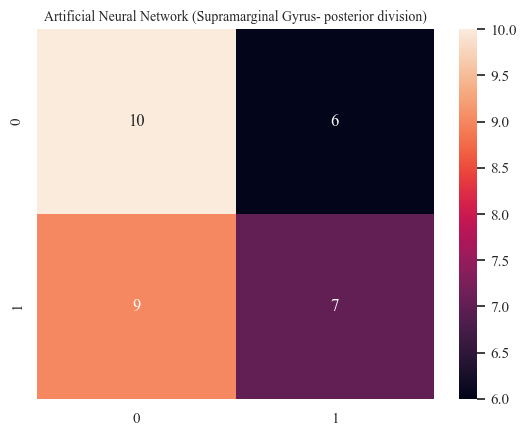

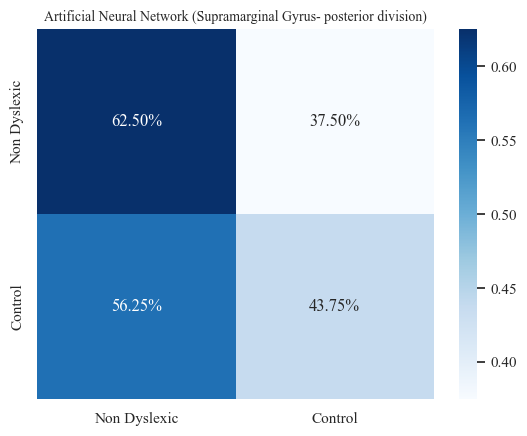

In [16]:
###### ANN Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])
# define the input shape
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=input_shape))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
ann_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Supramarginal Gyrus- posterior division (Artificial Neural Network): {ann_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus- posterior division (Artificial Neural Network): {ann_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus- posterior division (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))
ann_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus- posterior division (Artificial Neural Network): {ann_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network (Supramarginal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_2(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Supramarginal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_2(ANN)_percent.png", dpi=600)
plt.show()

Training Accuracy on Supramarginal Gyrus- posterior division (Random Forest): 100.00%
Testing Accuracy on Supramarginal Gyrus- posterior division (Random Forest): 50.00%

Classification Report for Testing Data on Supramarginal Gyrus- posterior division (Random Forest):
              precision    recall  f1-score   support

           0       0.50      0.75      0.60        16
           1       0.50      0.25      0.33        16

    accuracy                           0.50        32
   macro avg       0.50      0.50      0.47        32
weighted avg       0.50      0.50      0.47        32


ROC-AUC score for Testing Data on Supramarginal Gyrus- posterior division (Random Forest): 0.50


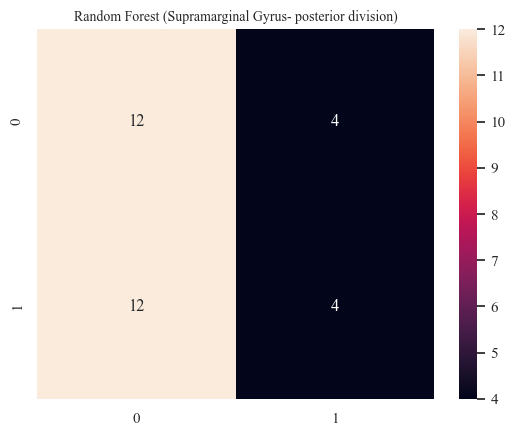

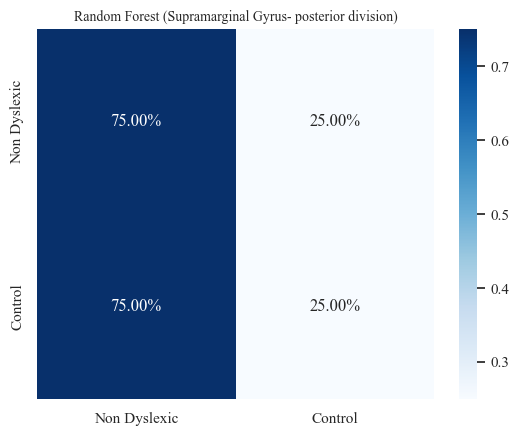

In [17]:
##### Random Forest model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Supramarginal Gyrus- posterior division (Random Forest): {rf_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus- posterior division (Random Forest): {rf_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus- posterior division (Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus- posterior division (Random Forest): {rf_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Random Forest (Supramarginal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_2(Rand_Forst)_simple.png", dpi=600)
plt.show() 
plt.title('Random Forest (Supramarginal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_2(Rand_Forst)_percent.png", dpi=600)
plt.show()

Training Accuracy on Supramarginal Gyrus- posterior division (XGBoost): 100.00%
Testing Accuracy on Supramarginal Gyrus- posterior division (XGBoost): 56.25%

Classification Report for Testing Data on Supramarginal Gyrus- posterior division (XGBoost):
              precision    recall  f1-score   support

           0       0.58      0.44      0.50        16
           1       0.55      0.69      0.61        16

    accuracy                           0.56        32
   macro avg       0.57      0.56      0.56        32
weighted avg       0.57      0.56      0.56        32


ROC-AUC score for Testing Data on Supramarginal Gyrus- posterior division (XGBoost): 0.56


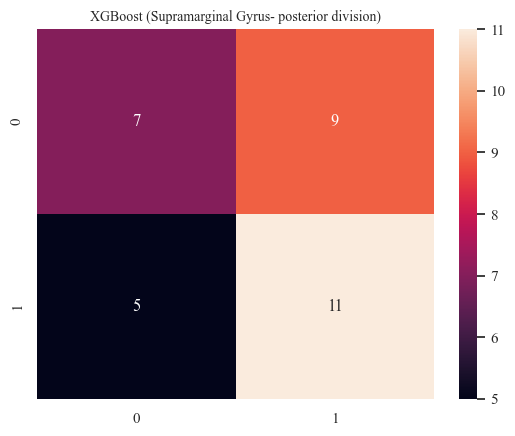

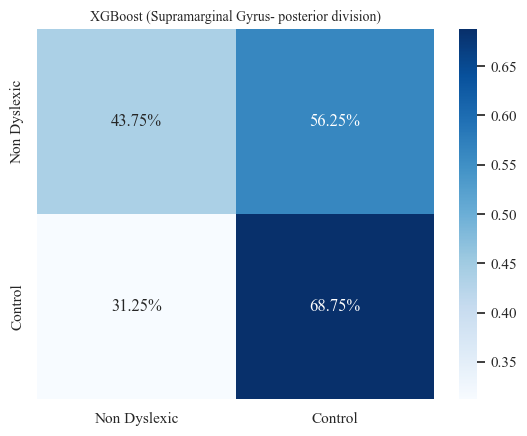

In [20]:
##### XGBoost (Extreme Gradient Boosting) model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Supramarginal Gyrus- posterior division (XGBoost): {xgb_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus- posterior division (XGBoost): {xgb_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus- posterior division (XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus- posterior division (XGBoost): {xgb_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('XGBoost (Supramarginal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_2(XGBst)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Supramarginal Gyrus- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_ROI_2(XGBst)_percent.png", dpi=600)
plt.show()

In [19]:
mean2=[]
mean2.append([round(log_mean_prf_ROI2[0][0],2),round(log_mean_prf_ROI2[1][0],2),round(log_mean_prf_ROI2[2][0],2),round(log_mean_test_accuracy_ROI2,2),round(log_mean_roc_ROI2,2)])
mean2.append([round(log_mean_prf_ROI2[0][1],2),round(log_mean_prf_ROI2[1][1],2),round(log_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(svm_mean_prf_ROI2[0][0],2),round(svm_mean_prf_ROI2[1][0],2),round(svm_mean_prf_ROI2[2][0],2),round(svm_mean_test_accuracy_ROI2,2),round(svm_mean_roc_ROI2,2)])
mean2.append([round(svm_mean_prf_ROI2[0][1],2),round(svm_mean_prf_ROI2[1][1],2),round(svm_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(knn_mean_prf_ROI2[0][0],2),round(knn_mean_prf_ROI2[1][0],2),round(knn_mean_prf_ROI2[2][0],2),round(knn_mean_test_accuracy_ROI2,2),round(knn_mean_roc_ROI2,2)])
mean2.append([round(knn_mean_prf_ROI2[0][1],2),round(knn_mean_prf_ROI2[1][1],2),round(knn_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(ann_mean_prf_ROI2[0][0],2),round(ann_mean_prf_ROI2[1][0],2),round(ann_mean_prf_ROI2[2][0],2),round(ann_mean_test_accuracy_ROI2,2),round(ann_mean_roc_ROI2,2)])
mean2.append([round(ann_mean_prf_ROI2[0][1],2),round(ann_mean_prf_ROI2[1][1],2),round(ann_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(rf_mean_prf_ROI2[0][0],2),round(rf_mean_prf_ROI2[1][0],2),round(rf_mean_prf_ROI2[2][0],2),round(rf_mean_test_accuracy_ROI2,2),round(rf_mean_roc_ROI2,2)])
mean2.append([round(rf_mean_prf_ROI2[0][1],2),round(rf_mean_prf_ROI2[1][1],2),round(rf_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(xgb_mean_prf_ROI2[0][0],2),round(xgb_mean_prf_ROI2[1][0],2),round(xgb_mean_prf_ROI2[2][0],2),round(xgb_mean_test_accuracy_ROI2,2),round(xgb_mean_roc_ROI2,2)])
mean2.append([round(xgb_mean_prf_ROI2[0][1],2),round(xgb_mean_prf_ROI2[1][1],2),round(xgb_mean_prf_ROI2[2][1],2),'',''])

df2 = pd.DataFrame(mean2,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Control']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
#df2=df2.style.set_sticky(axis="index")
df2.style.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}])
df2.style.set_caption("Table ROI_2 (Mean) Inferior Frontal Gyrus- pars opercularis")
display(df2)
df2.to_excel('../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Table_Mean_ROI_2_Supramarginal_Gyrus.xlsx', engine='openpyxl')


Precision  Recall  f1-score Accuracy  \
Logistic Regression        Non-Dyslexic       0.55    0.69      0.61     0.56   
                           Control            0.58    0.44      0.50            
Support Vector Machine     Non-Dyslexic       0.43    0.38      0.40     0.44   
                           Control            0.44    0.50      0.47            
k-nearest neighbors        Non-Dyslexic       0.50    1.00      0.67      0.5   
                           Control            0.00    0.00      0.00            
Artificial Neural Networks Non-Dyslexic       0.53    0.62      0.57     0.53   
                           Control            0.54    0.44      0.48            
Random Forest              Non-Dyslexic       0.50    0.75      0.60      0.5   
                           Control            0.50    0.25      0.33            
XGBoost                    Non-Dyslexic       0.58    0.44      0.50     0.56   
                           Control            0.55    0.69      0.61            

                                        roc_auc  
Logistic Regression        Non-Dyslexic    0.56  
                           Control               
Support Vector Machine     Non-Dyslexic    0.44  
                           Control               
k-nearest neighbors        Non-Dyslexic     0.5  
                           Control               
Artificial Neural Networks Non-Dyslexic    0.53  
                           Control               
Random Forest              Non-Dyslexic     0.5  
                           Control               
XGBoost                    Non-Dyslexic    0.56  
                           Control

## Combining ROIs  1 and 2 **(MEAN)**:- Supramarginal Gyrus- 1) Anterior division & 2) Posterior division 
#### Combining them into a single dataset to perform the experiments.

In [21]:
####Loading the saved dataset in np format.
cmd1 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/control_mean_anterior_division.npz")
ndmd1 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/non_dyslexic_mean_anterior_division.npz")
control_mean_data1 = cmd1["control_mean_data1"]
non_dyslexic_mean_data1=ndmd1["non_dyslexic_mean_data1"]
cmd2 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/control_mean_posterior_division.npz")
ndmd2 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/non_dyslexic_mean_posterior_division.npz")
control_mean_data2 = cmd2["control_mean_data2"]
non_dyslexic_mean_data2=ndmd2["non_dyslexic_mean_data2"]
####
print(len(control_mean_data1))
print(len(non_dyslexic_mean_data1))
print(len(control_mean_data2))
print(len(non_dyslexic_mean_data2))
print(control_mean_data1[0].shape)
print(non_dyslexic_mean_data1[0].shape)
print(control_mean_data2[0].shape)
print(non_dyslexic_mean_data2[0].shape)
print()
####Bringing the data to equal shape and size
control_m_d2=[]
non_dyslexic_m_d2=[]
for i in range(len(control_mean_data2)):
    control_m_d2.insert(i, np.pad(control_mean_data2[i], (0, control_mean_data1[0].shape[0]-control_mean_data2[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data1)):
    non_dyslexic_m_d2.insert(i, np.pad(non_dyslexic_mean_data2[i], (0, non_dyslexic_mean_data1[0].shape[0]-non_dyslexic_mean_data2[0].shape[0]), 'mean'))
print(control_mean_data1[0].shape)
print(non_dyslexic_mean_data1[0].shape)
print(control_m_d2[0].shape)
print(non_dyslexic_m_d2[0].shape)

80
80
80
80
(5153,)
(5153,)
(4273,)
(4273,)

(5153,)
(5153,)
(5153,)
(5153,)


In [22]:
# Combine the aggregated data from both groups
ll1=len(control_mean_data1)+len(control_m_d2)
ll2=len(non_dyslexic_mean_data1)+len(non_dyslexic_m_d2)
X = np.vstack([control_mean_data1,control_m_d2, non_dyslexic_mean_data1,non_dyslexic_m_d2])  # Shape: (n_samples, n_voxels)
y = np.array([1] * ll1 + [0] * ll2)  # Binary labels
print(X.shape)
print(y.shape)
##############################################################################################
##################### "If you want to save the Resultant Dataset" ############################
#np.savez("Data_Mask-Mean/Inferior_Frontal_Gyrus_Mean_Combine_1_2.npz", X=X, y=y)
##################### "If you want to save the Resultant Dataset" ############################
##############################################################################################

(320, 5153)
(320,)


Training Accuracy on Supramarginal Gyrus-anterior division & posterior division(Logistic regression): 100.00%
Testing Accuracy on Supramarginal Gyrus-anterior division & posterior division(Logistic regression): 48.44%

Classification Report for Testing Data on Supramarginal Gyrus-anterior division & posterior division(Logistic regression):
              precision    recall  f1-score   support

           0       0.49      0.66      0.56        32
           1       0.48      0.31      0.38        32

    accuracy                           0.48        64
   macro avg       0.48      0.48      0.47        64
weighted avg       0.48      0.48      0.47        64


ROC-AUC score for Testing Data on Supramarginal Gyrus-anterior division & posterior division(Logistic Regression): 0.48


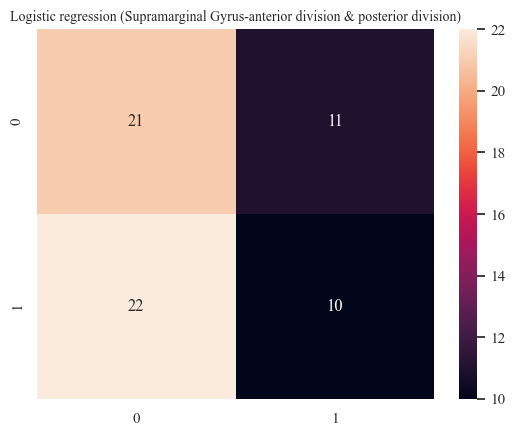

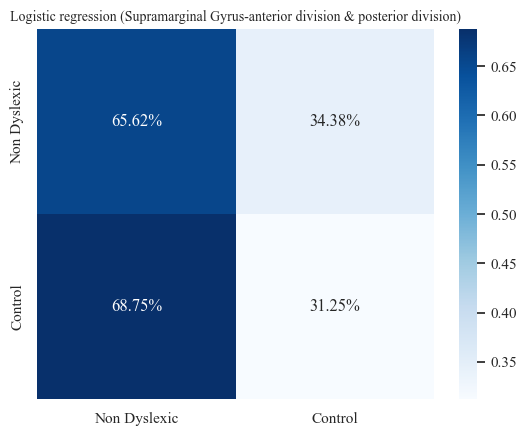

In [23]:
#Logistic regression
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Supramarginal Gyrus-anterior division & posterior division(Logistic regression): {log_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus-anterior division & posterior division(Logistic regression): {log_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus-anterior division & posterior division(Logistic regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)
# print(f"Precision 0:- {log_mean_prf_All_ROIs[0][0]:.2f}, Precision 1:- {log_mean_prf_All_ROIs[0][1]:.2f}")
# print(f"Recall 0:- {log_mean_prf_All_ROIs[1][0]:.2f}, Recall 1:- {log_mean_prf_All_ROIs[1][1]:.2f}")

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus-anterior division & posterior division(Logistic Regression): {log_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Logistic regression (Supramarginal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_All_ROIs(log_reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic regression (Supramarginal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_All_ROIs(log_reg)_percent.png", dpi=600)
plt.show()

Training Accuracy on Supramarginal Gyrus-anterior division & posterior division(Support Vector Machine): 92.58%
Testing Accuracy on Supramarginal Gyrus-anterior division & posterior division(Support Vector Machine): 50.00%

Classification Report for Testing Data on Supramarginal Gyrus-anterior division & posterior division(Support Vector Machine):
              precision    recall  f1-score   support

           0       0.50      0.81      0.62        32
           1       0.50      0.19      0.27        32

    accuracy                           0.50        64
   macro avg       0.50      0.50      0.45        64
weighted avg       0.50      0.50      0.45        64


ROC-AUC score for Testing Data on Supramarginal Gyrus-anterior division & posterior division(Support Vector Machine): 0.50


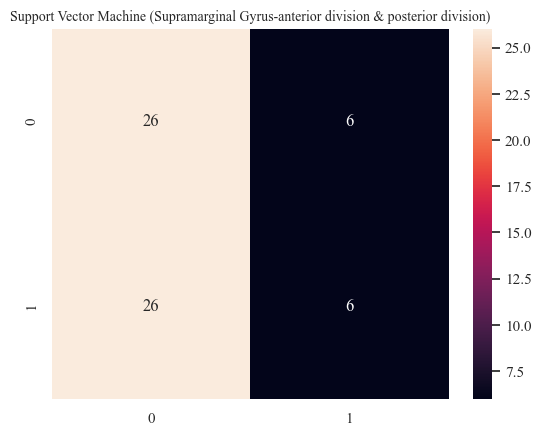

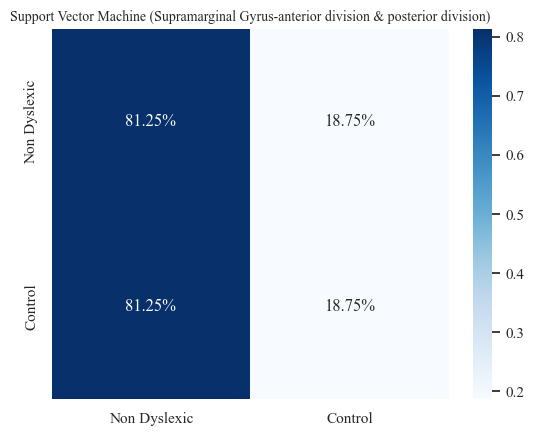

In [24]:
#Support Vector Machine
# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Evaluate the model
svm_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Supramarginal Gyrus-anterior division & posterior division(Support Vector Machine): {svm_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus-anterior division & posterior division(Support Vector Machine): {svm_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus-anterior division & posterior division(Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus-anterior division & posterior division(Support Vector Machine): {svm_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine (Supramarginal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_All_ROIs(svm)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Supramarginal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_All_ROIs(svm)_percent.png", dpi=600)
plt.show()

Training Accuracy on Supramarginal Gyrus-anterior division & posterior division(k-nearest neighbors): 87.50%
Testing Accuracy on Supramarginal Gyrus-anterior division & posterior division(k-nearest neighbors): 51.56%

Classification Report for Testing Data on Supramarginal Gyrus-anterior division & posterior division(k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.51      0.94      0.66        32
           1       0.60      0.09      0.16        32

    accuracy                           0.52        64
   macro avg       0.55      0.52      0.41        64
weighted avg       0.55      0.52      0.41        64


ROC-AUC score for Testing Data on Supramarginal Gyrus-anterior division & posterior division(k-nearest neighbors): 0.52


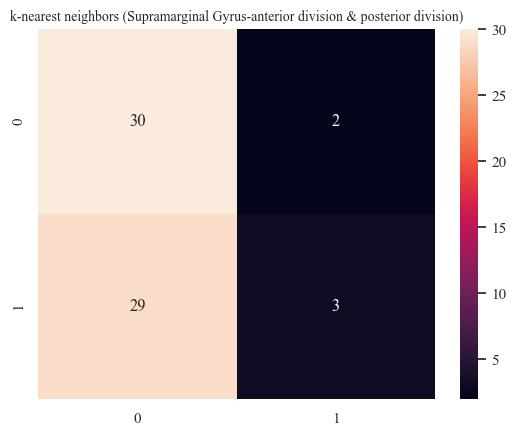

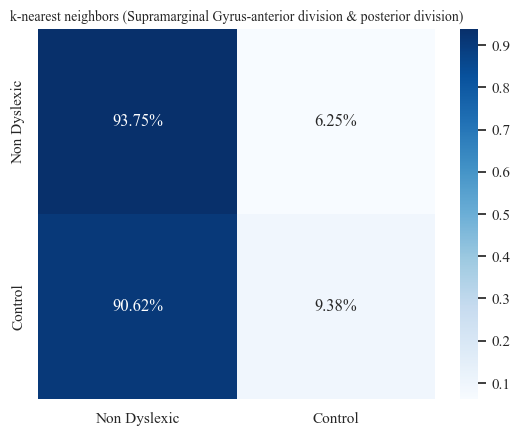

In [25]:
# k-nearest neighbors

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Supramarginal Gyrus-anterior division & posterior division(k-nearest neighbors): {knn_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus-anterior division & posterior division(k-nearest neighbors): {knn_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus-anterior division & posterior division(k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus-anterior division & posterior division(k-nearest neighbors): {knn_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors (Supramarginal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_All_ROIs(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Supramarginal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_All_ROIs(KNN)_percent.png", dpi=600)
plt.show()

In [26]:
print("Total Dataset:- ",X.shape)
print("Total Labels:- ",y.shape)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])


Total Dataset:-  (320, 5153)
Total Labels:-  (320,)
Total Training set:-  Dataset:- (256, 5153) Label:- (256,)
Total Testing set:-  Dataset:- (64, 5153) Label:- (64,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 512)                 │       2,638,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,714,881 (10.36 MB)

 Trainable params: 2,714,881 (10.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5016 - loss: 0.7759
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6469 - loss: 0.6372
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6677 - loss: 0.5852
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8057 - loss: 0.4596
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7859 - loss: 0.6022
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8385 - loss: 0.4331
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8625 - loss: 0.3541
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8990 - loss: 0.3280
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9354 - loss: 0.2735
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9365 - loss: 0.2153
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9255 - loss: 0.2235
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9719 - loss: 0.1799
E

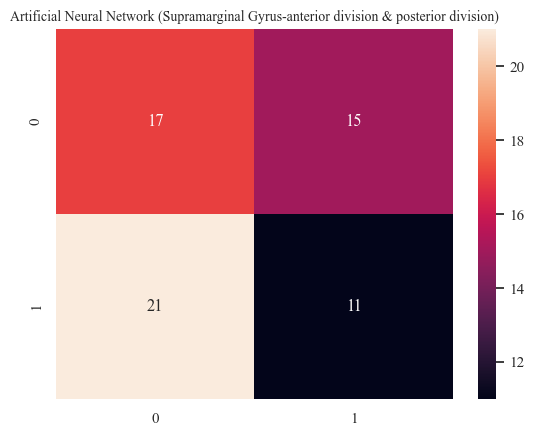

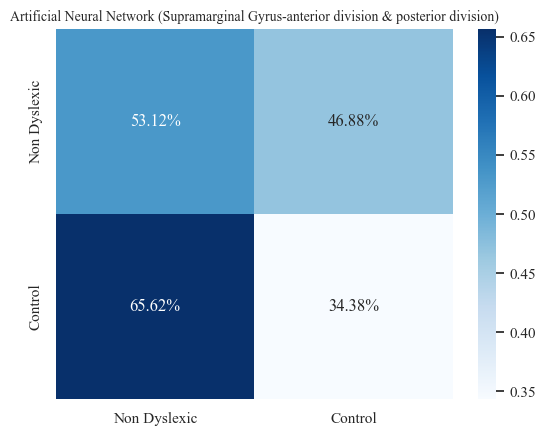

In [27]:
# Artificial Neural Network
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=input_shape))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
# Calculate training and testing accuracy
ann_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Supramarginal Gyrus-anterior division & posterior division(Artificial Neural Network): {ann_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus-anterior division & posterior division(Artificial Neural Network): {ann_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus-anterior division & posterior division(Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))

ann_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus-anterior division & posterior division(Artificial Neural Network): {ann_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network (Supramarginal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_All_ROIs(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Supramarginal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_All_ROIs(ANN)_percent.png", dpi=600)
plt.show()

Training Accuracy on Supramarginal Gyrus-anterior division & posterior division(Random Forest): 100.00%
Testing Accuracy on Supramarginal Gyrus-anterior division & posterior division(Random Forest): 57.81%

Classification Report for Testing Data on Supramarginal Gyrus-anterior division & posterior division(Random Forest):
              precision    recall  f1-score   support

           0       0.56      0.69      0.62        32
           1       0.60      0.47      0.53        32

    accuracy                           0.58        64
   macro avg       0.58      0.58      0.57        64
weighted avg       0.58      0.58      0.57        64


ROC-AUC score for Testing Data on Supramarginal Gyrus-anterior division & posterior division(Random Forest): 0.58


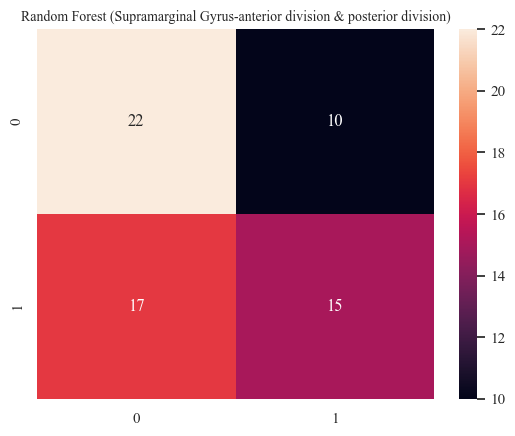

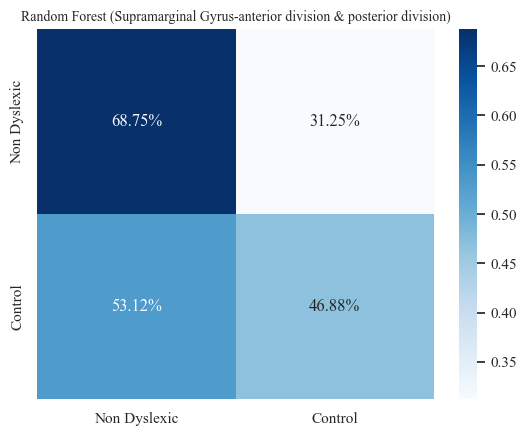

In [28]:
#Random Forest Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Supramarginal Gyrus-anterior division & posterior division(Random Forest): {rf_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus-anterior division & posterior division(Random Forest): {rf_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus-anterior division & posterior division(Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus-anterior division & posterior division(Random Forest): {rf_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Random Forest (Supramarginal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_All_ROIs(Rand_Frst)_simple.png", dpi=600)
plt.show() 
plt.title('Random Forest (Supramarginal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_All_ROIs(Rand_Frst)_percent.png", dpi=600)
plt.show()

Training Accuracy on Supramarginal Gyrus-anterior division & posterior division(XGBoost): 100.00%
Testing Accuracy on Supramarginal Gyrus-anterior division & posterior division(XGBoost): 59.38%

Classification Report for Testing Data on Supramarginal Gyrus-anterior division & posterior division(XGBoost):
              precision    recall  f1-score   support

           0       0.62      0.50      0.55        32
           1       0.58      0.69      0.63        32

    accuracy                           0.59        64
   macro avg       0.60      0.59      0.59        64
weighted avg       0.60      0.59      0.59        64


ROC-AUC score for Testing Data on Supramarginal Gyrus-anterior division & posterior division(XGBoost): 0.59


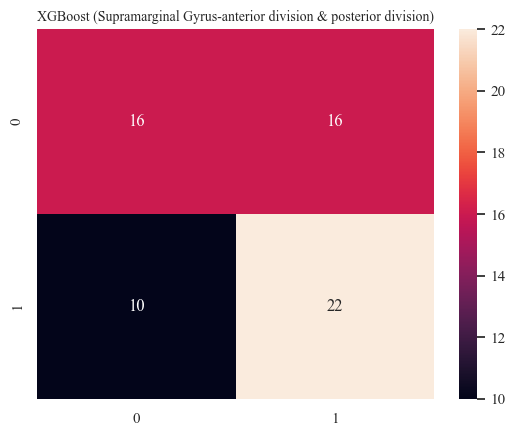

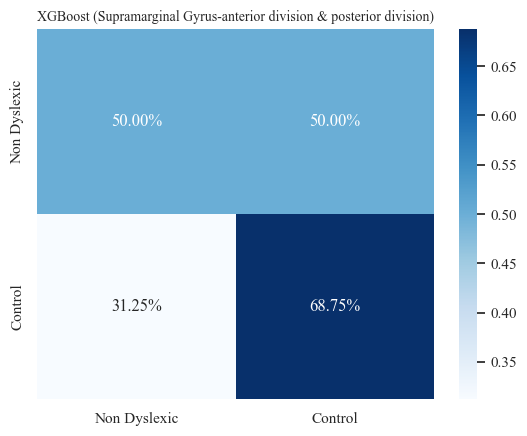

In [29]:
#XGBoost (Extreme Gradient Boosting) Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Supramarginal Gyrus-anterior division & posterior division(XGBoost): {xgb_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Supramarginal Gyrus-anterior division & posterior division(XGBoost): {xgb_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Supramarginal Gyrus-anterior division & posterior division(XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)
# print(f"Precision 0:- {log_mean_prf_All_ROIs[0][0]:.2f}, Precision 1:- {log_mean_prf_All_ROIs[0][1]:.2f}")
# print(f"Recall 0:- {log_mean_prf_All_ROIs[1][0]:.2f}, Recall 1:- {log_mean_prf_All_ROIs[1][1]:.2f}")

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Supramarginal Gyrus-anterior division & posterior division(XGBoost): {xgb_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('XGBoost (Supramarginal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_All_ROIs(XGBst)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Supramarginal Gyrus-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Supramarginal_Gyrus_All_ROIs(XGBst)_percent.png", dpi=600)
plt.show()

#### <b> Display results in dataframe tabular format (Comparison of all the models)</b>

In [30]:
mean_all=[]
mean_all.append([round(log_mean_prf_All_ROIs[0][0],2),round(log_mean_prf_All_ROIs[1][0],2),round(log_mean_prf_All_ROIs[2][0],2),round(log_mean_test_accuracy_All_ROIs,2),round(log_mean_roc_All_ROIs,2)])
mean_all.append([round(log_mean_prf_All_ROIs[0][1],2),round(log_mean_prf_All_ROIs[1][1],2),round(log_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(svm_mean_prf_All_ROIs[0][0],2),round(svm_mean_prf_All_ROIs[1][0],2),round(svm_mean_prf_All_ROIs[2][0],2),round(svm_mean_test_accuracy_All_ROIs,2),round(svm_mean_roc_All_ROIs,2)])
mean_all.append([round(svm_mean_prf_All_ROIs[0][1],2),round(svm_mean_prf_All_ROIs[1][1],2),round(svm_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(knn_mean_prf_All_ROIs[0][0],2),round(knn_mean_prf_All_ROIs[1][0],2),round(knn_mean_prf_All_ROIs[2][0],2),round(knn_mean_test_accuracy_All_ROIs,2),round(knn_mean_roc_All_ROIs,2)])
mean_all.append([round(knn_mean_prf_All_ROIs[0][1],2),round(knn_mean_prf_All_ROIs[1][1],2),round(knn_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(ann_mean_prf_All_ROIs[0][0],2),round(ann_mean_prf_All_ROIs[1][0],2),round(ann_mean_prf_All_ROIs[2][0],2),round(ann_mean_test_accuracy_All_ROIs,2),round(ann_mean_roc_All_ROIs,2)])
mean_all.append([round(ann_mean_prf_All_ROIs[0][1],2),round(ann_mean_prf_All_ROIs[1][1],2),round(ann_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(rf_mean_prf_All_ROIs[0][0],2),round(rf_mean_prf_All_ROIs[1][0],2),round(rf_mean_prf_All_ROIs[2][0],2),round(rf_mean_test_accuracy_All_ROIs,2),round(rf_mean_roc_All_ROIs,2)])
mean_all.append([round(rf_mean_prf_All_ROIs[0][1],2),round(rf_mean_prf_All_ROIs[1][1],2),round(rf_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(xgb_mean_prf_All_ROIs[0][0],2),round(xgb_mean_prf_All_ROIs[1][0],2),round(xgb_mean_prf_All_ROIs[2][0],2),round(xgb_mean_test_accuracy_All_ROIs,2),round(xgb_mean_roc_All_ROIs,2)])
mean_all.append([round(xgb_mean_prf_All_ROIs[0][1],2),round(xgb_mean_prf_All_ROIs[1][1],2),round(xgb_mean_prf_All_ROIs[2][1],2),'',''])

df3 = pd.DataFrame(mean_all,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Control']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
df3.style\
.set_caption("Comparison Table: Inferior Temporal Gyrus-anterior division, posterior division & temporooccipital part [All ROIs (Mean)]")\
.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee"),("text-align", "center")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee"),("text-align", "center")]}])
display(df3)
df3.to_excel('../../Figure_Output/5-Supramarginal_Gyrus/Output_Mean/Table_Mean_All_ROIs_Supramarginal_Gyrus.xlsx', engine='openpyxl')


Precision  Recall  f1-score Accuracy  \
Logistic Regression        Non-Dyslexic       0.49    0.66      0.56     0.48   
                           Control            0.48    0.31      0.38            
Support Vector Machine     Non-Dyslexic       0.50    0.81      0.62      0.5   
                           Control            0.50    0.19      0.27            
k-nearest neighbors        Non-Dyslexic       0.51    0.94      0.66     0.52   
                           Control            0.60    0.09      0.16            
Artificial Neural Networks Non-Dyslexic       0.45    0.53      0.49     0.44   
                           Control            0.42    0.34      0.38            
Random Forest              Non-Dyslexic       0.56    0.69      0.62     0.58   
                           Control            0.60    0.47      0.53            
XGBoost                    Non-Dyslexic       0.62    0.50      0.55     0.59   
                           Control            0.58    0.69      0.63            

                                        roc_auc  
Logistic Regression        Non-Dyslexic    0.48  
                           Control               
Support Vector Machine     Non-Dyslexic     0.5  
                           Control               
k-nearest neighbors        Non-Dyslexic    0.52  
                           Control               
Artificial Neural Networks Non-Dyslexic    0.44  
                           Control               
Random Forest              Non-Dyslexic    0.58  
                           Control               
XGBoost                    Non-Dyslexic    0.59  
                           Control